In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

# Create a sample DataFrame with different missingness patterns
data = {
    'A': np.random.rand(100),
    'B': np.random.randint(1, 10, 100),
    'C': np.random.normal(0, 1, 100),
    'D': np.random.choice([np.nan, 1, 2, 3], 100, p=[0.1, 0.3, 0.3, 0.3])
}
df = pd.DataFrame(data)

# Introduce some MCAR
df.loc[np.random.choice(df.index, 5), 'A'] = np.nan
df.loc[np.random.choice(df.index, 3), 'B'] = np.nan

# Introduce some MAR (e.g., 'C' is missing when 'A' is high)
df.loc[df['A'] > 0.8, 'C'] = np.nan
# Introduce some MNAR (e.g., 'D' is missing more often for value 1) - this is hard to simulate perfectly for demonstration
# Let's just make 'D' missing based on its own value's propensity (true MNAR is tough to "see" directly without knowing the true value)
df.loc[(df['D'] == 1) & (np.random.rand(len(df)) < 0.3), 'D'] = np.nan


print(df.head())
print("\nMissing values count:\n", df.isnull().sum())


          A    B         C    D
0  0.459933  1.0 -1.239021  3.0
1  0.882407  7.0       NaN  2.0
2  0.846310  9.0       NaN  2.0
3  0.679914  4.0  1.748704  2.0
4  0.393674  2.0  0.452153  2.0

Missing values count:
 A     5
B     3
C    25
D    14
dtype: int64


In [18]:
import statsmodels.api as sm
?sm.GLM

Init signature:
sm.GLM(
    endog,
    exog,
    family=None,
    offset=None,
    exposure=None,
    freq_weights=None,
    var_weights=None,
    missing='none',
    **kwargs,
)
Docstring:     
Generalized Linear Models

GLM inherits from statsmodels.base.model.LikelihoodModel

Parameters
----------
endog : array_like
    1d array of endogenous response variable.  This array can be 1d or 2d.
    Binomial family models accept a 2d array with two columns. If
    supplied, each observation is expected to be [success, failure].
exog : array_like
    A nobs x k array where `nobs` is the number of observations and `k`
    is the number of regressors. An intercept is not included by default
    and should be added by the user (models specified using a formula
    include an intercept by default). See `statsmodels.tools.add_constant`.
family : family class instance
    The default is Gaussian.  To specify the binomial distribution
    family = sm.family.Binomial()
    Each family can take a l

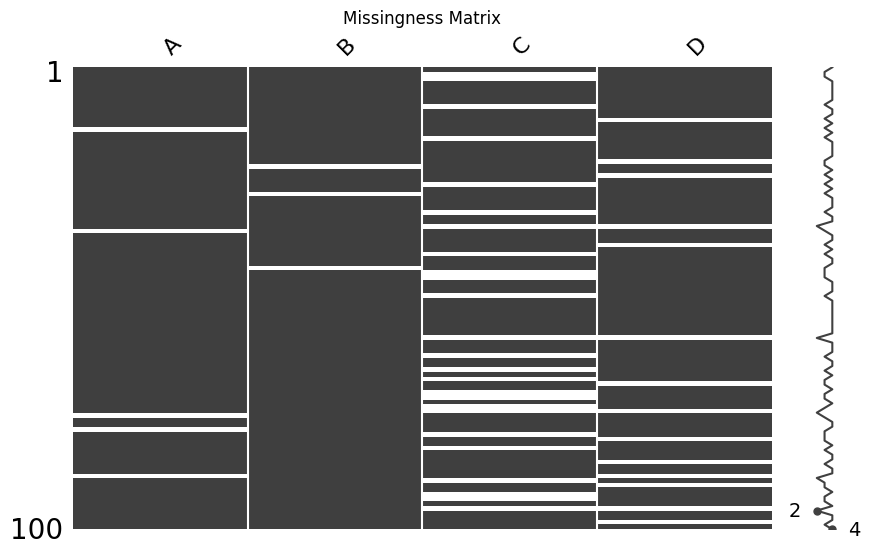

In [2]:

# missingno visualizations:

# 1. Matrix plot: Shows the distribution of missingness.
msno.matrix(df, figsize=(10, 6))
plt.title("Missingness Matrix")
plt.show()


<Axes: >

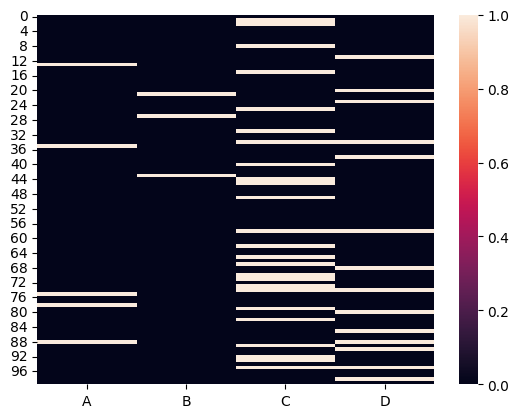

In [3]:
import seaborn as sns
sns.heatmap(df.isna())

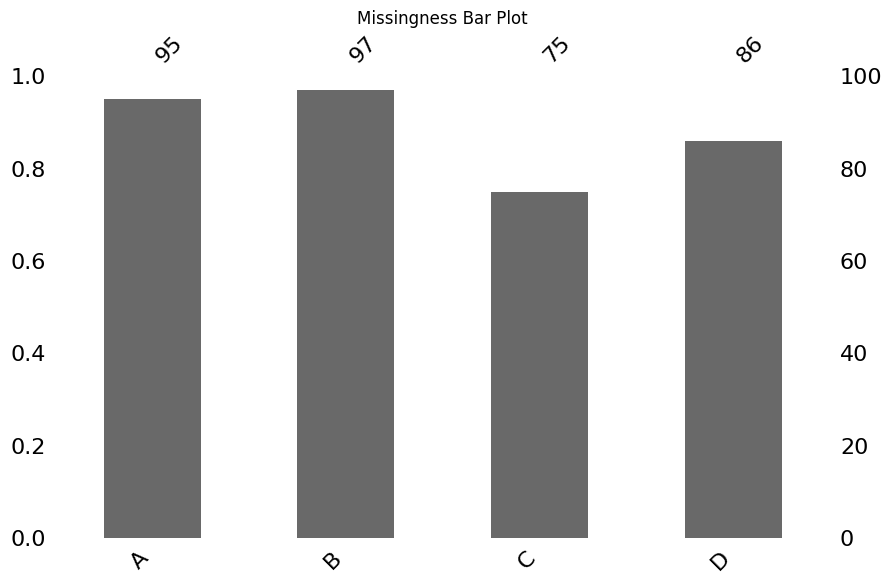

In [5]:
# 2. Bar plot: Visualizes the count/percentage of missingness per column.
msno.bar(df, figsize=(10, 6))
plt.title("Missingness Bar Plot")
plt.show()


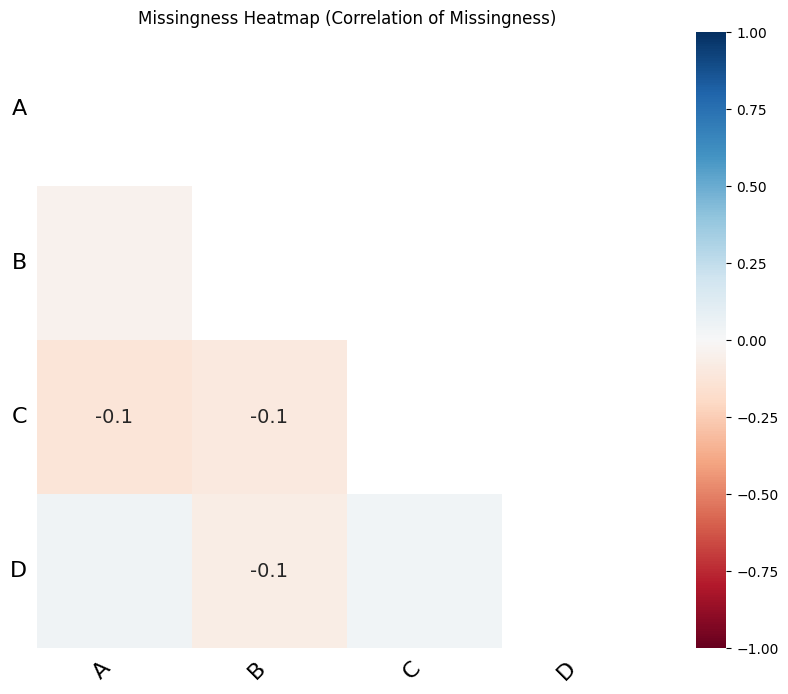

In [7]:

# 3. Heatmap: Shows correlation of missingness between variables.
# A value of 1 means if one is missing, the other is also missing. -1 means if one is missing, the other is NOT missing.
msno.heatmap(df, figsize=(10, 8), labels=True)
plt.title("Missingness Heatmap (Correlation of Missingness)")
plt.show()


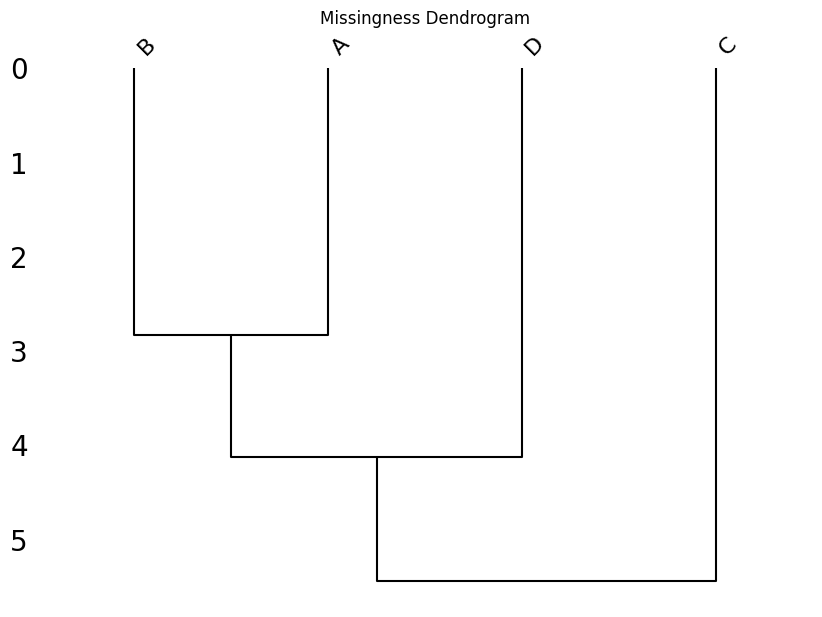

In [ ]:
# 4. Dendrogram: Hierarchical clustering of missingness (groups columns with similar missingness patterns).
msno.dendrogram(df, figsize=(10, 7))
plt.title("Missingness Dendrogram")
plt.show()